In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

%matplotlib inline

In [46]:
df = pd.read_csv('integrateddd_data.csv')
df =df[
    (df['category'] != 'Unknown') &
    (df['url'] != 'No URL')
]


In [47]:
df

,url,title,category,duration_seconds,view_count,like_count,comment_count
0,https://www.youtube.com/watch?v=_uQrJ0TkZlc,Python Full Course for Beginners,python tutorial,22447.0,46484976,1226186.0,61315.0
1,https://www.youtube.com/watch?v=kqtD5dpn9C8,Python for Beginners - Learn Coding with Pytho...,python tutorial,3606.0,23266146,532774.0,26625.0
2,https://www.youtube.com/watch?v=rfscVS0vtbw,Learn Python - Full Course for Beginners [Tuto...,python tutorial,16012.0,48131277,1109421.0,45939.0
3,https://www.youtube.com/watch?v=t8pPdKYpowI,Python Tutorial for Beginners - Learn Python i...,python tutorial,19890.0,6599656,167519.0,4008.0
4,https://www.youtube.com/watch?v=K5KVEU3aaeQ,Python Full Course for Beginners [2025],python tutorial,7341.0,4613318,112457.0,3020.0
...,...,...,...,...,...,...,...
1737,https://www.youtube.com/watch?v=VjzsAJa27mU,"Zhao Yunshan, Chongqing April 12, 2024 #chinat...",travelling,14.0,19465999,432499.0,10296.0
1738,https://www.youtube.com/watch?v=4jrk81foQx8,"PACK, PREP AND TRAVEL W ME TO HAWAII FOR A MON...",travelling,1014.0,111869,3228.0,80.0
1739,https://www.youtube.com/watch?v=e7pkte-fuOU,Wonders of Greece | Most Amazing Places in Gre...,travelling,3607.0,439933,3143.0,132.0
1740,https://www.youtube.com/watch?v=x_ywByCJ0hk,Things to BEWARE OF IN SOUTH KOREA 😬 #travel #...,travelling,60.0,368443,5535.0,594.0


In [48]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 url                 0
title               0
category            0
duration_seconds    0
view_count          0
like_count          0
comment_count       0
dtype: int64


In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1742 entries, 0 to 1741
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               1742 non-null   object 
 1   title             1742 non-null   object 
 2   category          1742 non-null   object 
 3   duration_seconds  1742 non-null   float64
 4   view_count        1742 non-null   int64  
 5   like_count        1742 non-null   float64
 6   comment_count     1742 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 108.9+ KB
None


In [50]:
print(df.describe())

       duration_seconds    view_count    like_count  comment_count
count       1742.000000  1.742000e+03  1.742000e+03    1742.000000
mean        1004.097589  1.408322e+07  2.781855e+05    2777.353617
std         4232.720906  4.766340e+07  9.561306e+05   14008.137618
min            0.000000  1.000000e+00  0.000000e+00       0.000000
25%           20.000000  2.272732e+05  5.327500e+03      84.250000
50%           50.000000  1.585916e+06  3.196350e+04     403.000000
75%          364.500000  9.180792e+06  1.901682e+05    1626.000000
max        57468.000000  1.225592e+09  1.979052e+07  440712.000000


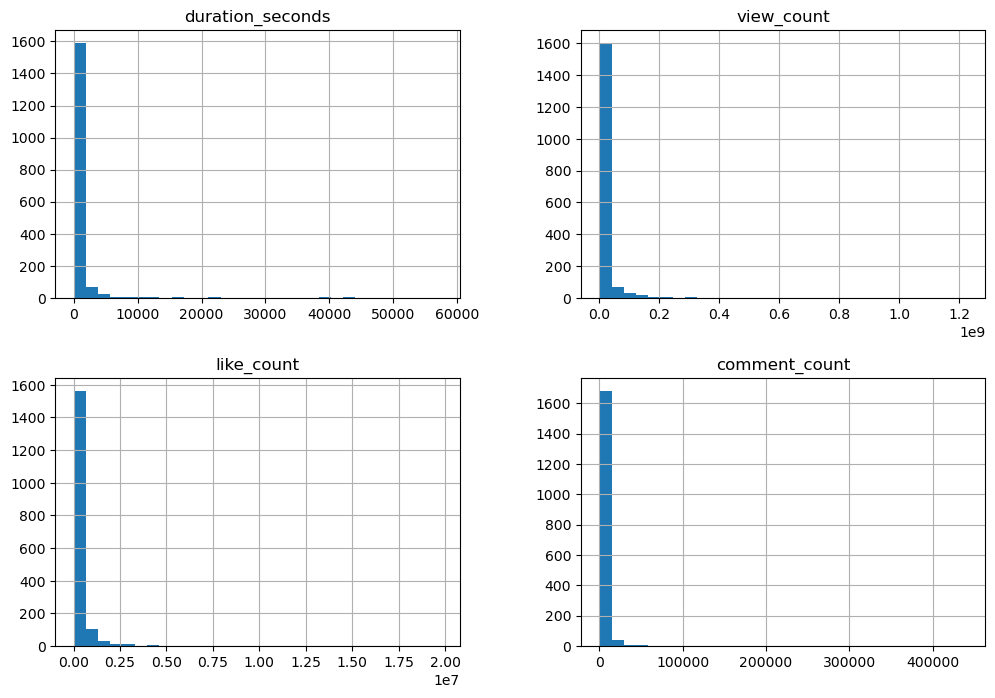

In [51]:
numeric_cols = ['duration_seconds','view_count','like_count','comment_count']

# Histograms
df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.show()

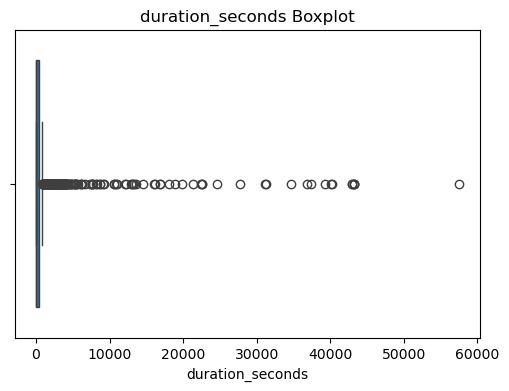

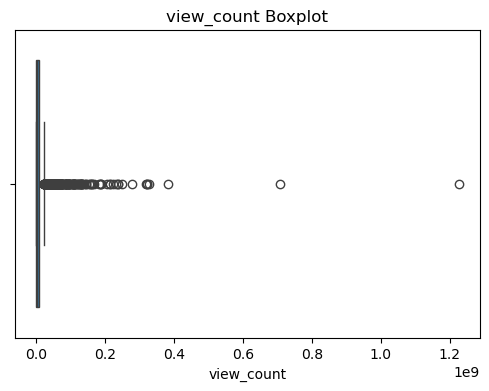

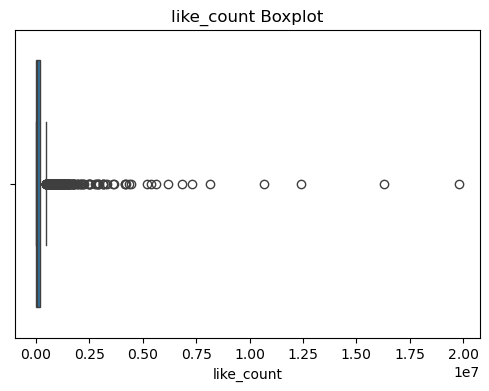

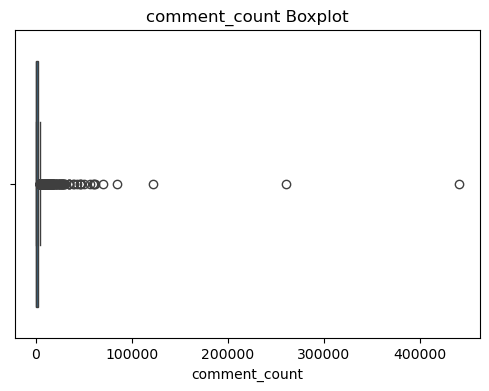

In [52]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

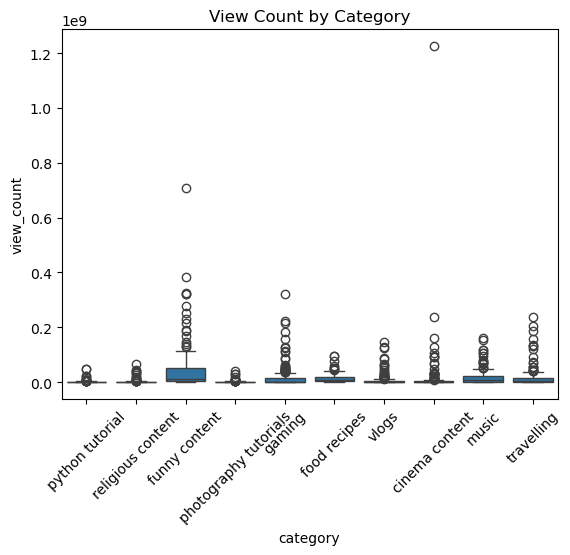

In [53]:
sns.boxplot(x='category', y='view_count', data=df)
plt.xticks(rotation=45)
plt.title('View Count by Category')
plt.show()

In [54]:
print("\nCorrelation:\n", df[numeric_cols].corr())
print("\nCovariance:\n", df[numeric_cols].cov())


Correlation:
                   duration_seconds  view_count  like_count  comment_count
duration_seconds          1.000000   -0.046659   -0.039593       0.054877
view_count               -0.046659    1.000000    0.870190       0.137766
like_count               -0.039593    0.870190    1.000000       0.190408
comment_count             0.054877    0.137766    0.190408       1.000000

Covariance:
                   duration_seconds    view_count    like_count  comment_count
duration_seconds      1.791593e+07 -9.413201e+09 -1.602326e+08   3.253808e+06
view_count           -9.413201e+09  2.271800e+15  3.965666e+13   9.198270e+10
like_count           -1.602326e+08  3.965666e+13  9.141858e+11   2.550244e+09
comment_count         3.253808e+06  9.198270e+10  2.550244e+09   1.962279e+08


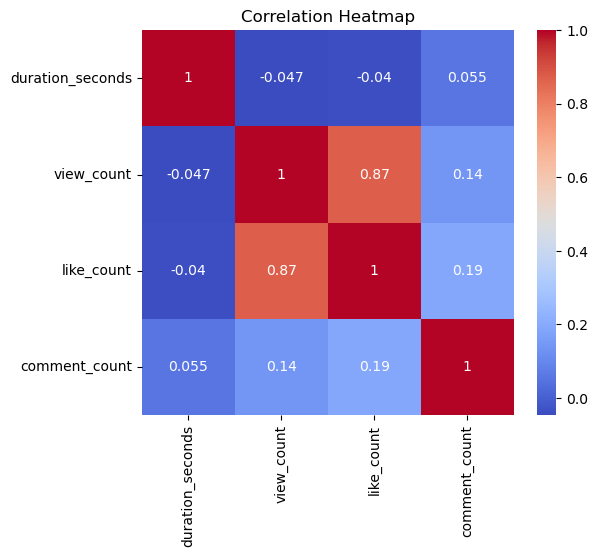

In [55]:
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [56]:
category_counts = df['category'].value_counts()
print("\nCategory counts:\n", category_counts)



Category counts:
 category
gaming                   195
travelling               190
photography tutorials    188
vlogs                    183
funny content            182
python tutorial          182
cinema content           174
music                    165
religious content        161
food recipes             122
Name: count, dtype: int64


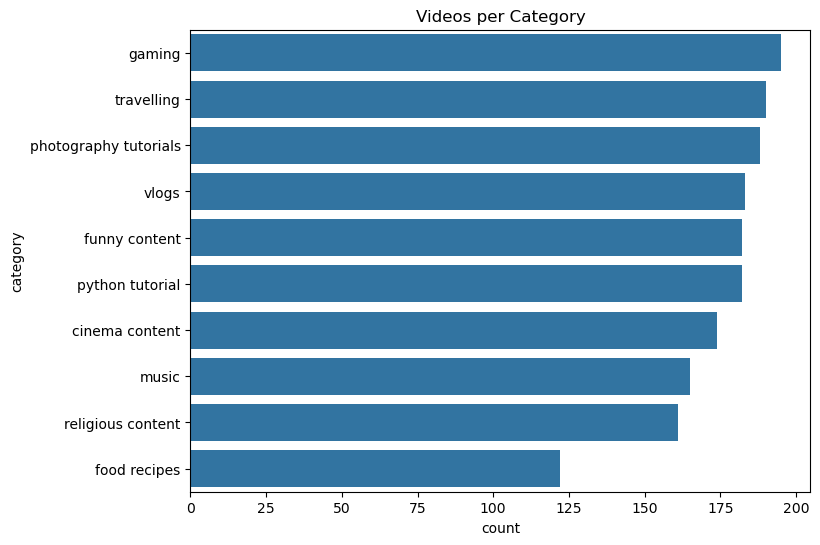

In [57]:
plt.figure(figsize=(8,6))
sns.countplot(y='category', data=df, order=category_counts.index)
plt.title('Videos per Category')
plt.show()

In [58]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]


In [59]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))


duration_seconds outliers: 305
view_count outliers: 239
like_count outliers: 234
comment_count outliers: 242


In [60]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)


In [61]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))

duration_seconds outliers: 0
view_count outliers: 0
like_count outliers: 0
comment_count outliers: 0


In [65]:
# Engagement rate feature
df['engagement'] = (
    df['like_count'] + df['comment_count']
) / df['view_count']


In [66]:
df

,url,title,category,duration_seconds,view_count,like_count,comment_count,engagement
0,https://www.youtube.com/watch?v=_uQrJ0TkZlc,Python Full Course for Beginners,python tutorial,881.25,2.261107e+07,467429.375,3938.625,0.020847
1,https://www.youtube.com/watch?v=kqtD5dpn9C8,Python for Beginners - Learn Coding with Pytho...,python tutorial,881.25,2.261107e+07,467429.375,3938.625,0.020847
2,https://www.youtube.com/watch?v=rfscVS0vtbw,Learn Python - Full Course for Beginners [Tuto...,python tutorial,881.25,2.261107e+07,467429.375,3938.625,0.020847
3,https://www.youtube.com/watch?v=t8pPdKYpowI,Python Tutorial for Beginners - Learn Python i...,python tutorial,881.25,6.599656e+06,167519.000,3938.625,0.025980
4,https://www.youtube.com/watch?v=K5KVEU3aaeQ,Python Full Course for Beginners [2025],python tutorial,881.25,4.613318e+06,112457.000,3020.000,0.025031
...,...,...,...,...,...,...,...,...
1737,https://www.youtube.com/watch?v=VjzsAJa27mU,"Zhao Yunshan, Chongqing April 12, 2024 #chinat...",travelling,14.00,1.946600e+07,432499.000,3938.625,0.022421
1738,https://www.youtube.com/watch?v=4jrk81foQx8,"PACK, PREP AND TRAVEL W ME TO HAWAII FOR A MON...",travelling,881.25,1.118690e+05,3228.000,80.000,0.029570
1739,https://www.youtube.com/watch?v=e7pkte-fuOU,Wonders of Greece | Most Amazing Places in Gre...,travelling,881.25,4.399330e+05,3143.000,132.000,0.007444
1740,https://www.youtube.com/watch?v=x_ywByCJ0hk,Things to BEWARE OF IN SOUTH KOREA 😬 #travel #...,travelling,60.00,3.684430e+05,5535.000,594.000,0.016635


In [67]:
# Save to CSV
df.to_csv('integratedEDA_data.csv', index=False)

# Confirm
print("Integrated dataset saved to 'integratedEDA_data.csv'")

Integrated dataset saved to 'integratedEDA_data.csv'
